# Classifier artifact assessment

Load one saved classifier, reconstruct its deterministic test split, and compare it with the benchmark configured in framework.yaml.

In [1]:
from copy import deepcopy
from pathlib import Path
import json
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from matplotlib.lines import Line2D
from sklearn.metrics import (
    auc,
    average_precision_score,
    precision_recall_curve,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from torch.utils.data import DataLoader

In [2]:
ROOT = Path.cwd().resolve()
if not (ROOT / "artifacts").exists():
    ROOT = ROOT.parent
if not (ROOT / "artifacts").exists():
    raise FileNotFoundError("Run this notebook from the repository or notebooks directory")
sys.path.insert(0, str(ROOT))

from src.benchmark import build_benchmark
from src.data import fit_standardizer, make_dataset, split_indices
from src.hashing import calculate_run_id
from src.model import build_model
from src.training import build_loss

## Select and load one artifact

In [3]:
PROJECT_BASENAME = "bmra_student_project"
RUN_ID = "2480667c9a2c"

artifact_dir = ROOT / "artifacts" / PROJECT_BASENAME / RUN_ID
required_files = {
    "model.pt",
    "framework.yaml",
    f"{PROJECT_BASENAME}.yaml",
    "metrics.json",
    "training_history.csv",
}
missing_files = [name for name in required_files if not (artifact_dir / name).exists()]
if missing_files:
    raise FileNotFoundError(f"Missing artifact files in {artifact_dir}: {missing_files}")
artifact_dir

PosixPath('/media/chnguyen47/ADATA/Projects/BMRA_modular_MLC/artifacts/bmra_student_project/2480667c9a2c')

In [4]:
framework = yaml.safe_load((artifact_dir / "framework.yaml").read_bytes())
project = yaml.safe_load((artifact_dir / f"{PROJECT_BASENAME}.yaml").read_bytes())
history = pd.read_csv(artifact_dir / "training_history.csv")
metrics = json.loads((artifact_dir / "metrics.json").read_text(encoding="utf-8"))
active_framework = yaml.safe_load((ROOT / "configs/framework.yaml").read_bytes())
benchmark_config = framework.get("benchmark", active_framework["benchmark"])
benchmark_name = {
    "xgboost": "XGBoost",
    "decision_tree": "Decision Tree",
}.get(benchmark_config["type"], benchmark_config["type"])
cv_metrics = metrics.get("cross_validation", {})
selected_framework = deepcopy(framework)
selected_candidate = cv_metrics.get("selected_candidate", {})
for section in ("model", "training"):
    selected_framework[section].update(selected_candidate.get(section, {}))

resolved_config = {**framework, "project": {**framework["project"], **project}}
calculated_run_id = calculate_run_id(resolved_config)
if calculated_run_id != RUN_ID:
    raise ValueError(f"Artifact/config hash mismatch: {RUN_ID} != {calculated_run_id}")

summary = pd.Series(
    {
        "project": PROJECT_BASENAME,
        "run_id": RUN_ID,
        "features": len(project["features"]),
        "labels": len(project["labels"]),
        "epochs_trained": len(history),
        "best_epoch": metrics.get("best_epoch"),
        "stopped_early": metrics.get("stopped_early"),
        "split_strategy": framework["split"].get("strategy", "legacy random"),
        "group_column": framework["split"].get("group_column"),
        "cv_folds": cv_metrics.get("folds"),
        "selected_candidate": selected_candidate.get("name"),
        "final_epoch_rule": framework.get("cross_validation", {}).get("final_epochs"),
        "cv_fold_best_epochs": cv_metrics.get("fold_best_epochs"),
        "selected_global_threshold": cv_metrics.get("selected_global_threshold"),
        "benchmark": benchmark_name,
        "benchmark_config_source": (
            "artifact snapshot" if "benchmark" in framework else "active framework fallback"
        ),
    },
    name="value",
)
display(summary, pd.DataFrame(metrics.get("test", {}), index=["saved_test"]))

project                      bmra_student_project
run_id                               2480667c9a2c
features                                      315
labels                                         76
epochs_trained                                 20
best_epoch                                     20
stopped_early                               False
split_strategy                 grouped_multilabel
group_column                                   ID
cv_folds                                        3
selected_candidate            compact_regularized
final_epoch_rule                median_best_epoch
cv_fold_best_epochs                  [20, 21, 17]
selected_global_threshold                     0.2
benchmark                                 XGBoost
benchmark_config_source         artifact snapshot
Name: value, dtype: object

,accuracy,loss,micro_f1
saved_test,0.93645,0.131894,0.403573


## Training history

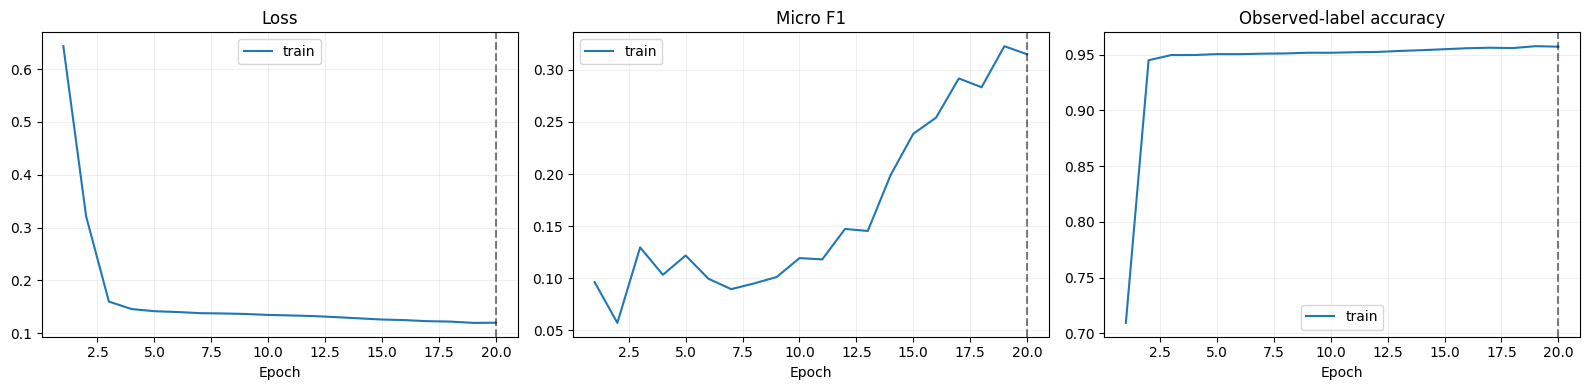

,epoch,train_accuracy,train_micro_f1,train_loss
15,16,0.955756,0.254174,0.124606
16,17,0.956191,0.291782,0.122610
17,18,0.955888,0.283369,0.121819
18,19,0.957596,0.322789,0.119368
19,20,0.957141,0.314973,0.119710


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for axis, metric, title in zip(
    axes, ["loss", "micro_f1", "accuracy"], ["Loss", "Micro F1", "Observed-label accuracy"]
):
    axis.plot(history["epoch"], history[f"train_{metric}"], label="train")
    if f"val_{metric}" in history:
        axis.plot(history["epoch"], history[f"val_{metric}"], label="validation")
    if metrics.get("best_epoch") is not None:
        axis.axvline(metrics["best_epoch"], color="black", linestyle="--", alpha=0.5)
    axis.set(title=title, xlabel="Epoch")
    axis.grid(alpha=0.2)
    axis.legend()
plt.tight_layout()
plt.show()
history.tail()

## Reconstruct the test split and run inference

In [6]:
data_path = ROOT / framework["data"]["path"]
frame = pd.read_parquet(data_path)
feature_columns = project["features"]
label_columns = project["labels"]
missing_columns = set(feature_columns + label_columns) - set(frame.columns)
if missing_columns:
    raise ValueError(f"Columns missing from evaluation data: {sorted(missing_columns)}")

split = framework["split"]
train_idx, val_idx, test_idx = split_indices(
    len(frame),
    split["train"],
    split["val"],
    split["test"],
    split["seed"],
    frame=frame,
    label_columns=label_columns,
    strategy=split.get("strategy", "random"),
    group_column=split.get("group_column"),
)
diagnostic_group = split.get("group_column", "ID" if "ID" in frame else None)
if diagnostic_group:
    split_indices_by_name = {"train": train_idx, "val": val_idx, "test": test_idx}
    split_groups = {
        name: set(frame.iloc[indices][diagnostic_group])
        for name, indices in split_indices_by_name.items()
    }
    group_overlap = {
        "train/val": len(split_groups["train"] & split_groups["val"]),
        "train/test": len(split_groups["train"] & split_groups["test"]),
        "val/test": len(split_groups["val"] & split_groups["test"]),
    }
    print(
        f"split strategy: {split.get('strategy', 'legacy random')}; "
        f"{diagnostic_group} overlap: {group_overlap}"
    )
    if any(group_overlap.values()):
        print("Warning: retrain this legacy artifact with grouped_multilabel splitting.")
development_idx = np.sort(np.concatenate([train_idx, val_idx]))
fit_idx = development_idx if cv_metrics.get("enabled") else train_idx
means, scales = fit_standardizer(frame.iloc[fit_idx], feature_columns)
train_data = make_dataset(frame.iloc[fit_idx], feature_columns, label_columns, means, scales)
test_data = make_dataset(frame.iloc[test_idx], feature_columns, label_columns, means, scales)
test_loader = DataLoader(
    test_data, batch_size=selected_framework["training"]["batch_size"]
)
len(test_data)

split strategy: grouped_multilabel; ID overlap: {'train/val': 0, 'train/test': 0, 'val/test': 0}


235

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_model(selected_framework, project).to(device)
model.load_state_dict(torch.load(artifact_dir / "model.pt", map_location=device, weights_only=True))
model.eval()
criterion = build_loss(framework["loss"]).to(device)

all_logits, all_targets, all_masks = [], [], []
with torch.no_grad():
    for features, targets, feature_mask, label_mask in test_loader:
        logits = model(features.to(device), feature_mask.to(device))
        all_logits.append(logits.cpu())
        all_targets.append(targets)
        all_masks.append(label_mask)

logits = torch.cat(all_logits)
targets = torch.cat(all_targets)
availability = torch.cat(all_masks).bool()
probabilities = torch.sigmoid(logits)
threshold_by_label = cv_metrics.get("label_thresholds", {})
decision_thresholds = torch.tensor(
    [threshold_by_label.get(label, 0.5) for label in label_columns]
)
predictions = probabilities >= decision_thresholds
test_loss = criterion(logits, targets, availability).item()
logits.shape, test_loss

(torch.Size([235, 76]), 0.13189436495304108)

## Fit the configured benchmark

Fit one XGBoost classifier per label using only that label's available training targets. Class weights are derived independently per label. The configured decision tree is used if XGBoost is unavailable or fails to fit.

In [8]:
train_features, train_targets, train_feature_masks, train_label_masks = train_data.tensors
test_features, _, test_feature_masks, _ = test_data.tensors
benchmark = build_benchmark(benchmark_config).fit(
    train_features.numpy(),
    train_targets.numpy(),
    train_feature_masks.numpy(),
    train_label_masks.numpy(),
)
benchmark_probability_array = benchmark.predict_proba(
    test_features.numpy(), test_feature_masks.numpy()
)
benchmark_probability_array.shape, benchmark.backend_counts()

((235, 76), {'xgboost': 76})

## MLC versus benchmark metrics

All metrics use the same held-out test rows and ignore unavailable labels.

In [9]:
target_array = targets.numpy().astype(int)
probability_array = probabilities.numpy()
mask_array = availability.numpy()

def evaluate_scores(score_array, thresholds=0.5):
    threshold_array = np.asarray(thresholds)
    prediction_array = score_array >= threshold_array
    per_label_rows = []
    for index, label in enumerate(label_columns):
        observed = mask_array[:, index]
        y_true = target_array[observed, index]
        y_score = score_array[observed, index]
        y_pred = prediction_array[observed, index]
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average="binary", zero_division=0
        )
        has_both_classes = len(np.unique(y_true)) == 2
        per_label_rows.append(
            {
                "label": label,
                "support": len(y_true),
                "positive_count": int(y_true.sum()),
                "negative_count": int(len(y_true) - y_true.sum()),
                "threshold": (
                    float(threshold_array) if threshold_array.ndim == 0 else threshold_array[index]
                ),
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "roc_auc": roc_auc_score(y_true, y_score) if has_both_classes else np.nan,
                "average_precision": (
                    average_precision_score(y_true, y_score) if has_both_classes else np.nan
                ),
            }
        )
    per_label_metrics = pd.DataFrame(per_label_rows).set_index("label")
    flat_targets = target_array[mask_array]
    flat_scores = score_array[mask_array]
    flat_predictions = prediction_array[mask_array]
    micro_precision, micro_recall, micro_f1, _ = precision_recall_fscore_support(
        flat_targets, flat_predictions, average="binary", zero_division=0
    )
    row_has_labels = mask_array.any(axis=1)
    row_correct = ((prediction_array == target_array) | ~mask_array).all(axis=1)
    clipped_scores = np.clip(flat_scores, 1e-7, 1 - 1e-7)
    masked_bce = -np.mean(
        flat_targets * np.log(clipped_scores)
        + (1 - flat_targets) * np.log(1 - clipped_scores)
    )
    evaluation_metrics = pd.Series(
        {
            "masked_bce": masked_bce,
            "observed_accuracy": (flat_predictions == flat_targets).mean(),
            "subset_accuracy": row_correct[row_has_labels].mean(),
            "micro_precision": micro_precision,
            "micro_recall": micro_recall,
            "micro_f1": micro_f1,
            "macro_precision": per_label_metrics["precision"].mean(),
            "macro_recall": per_label_metrics["recall"].mean(),
            "macro_f1": per_label_metrics["f1"].mean(),
            "micro_roc_auc": roc_auc_score(flat_targets, flat_scores),
            "macro_roc_auc": per_label_metrics["roc_auc"].mean(),
            "micro_average_precision": average_precision_score(flat_targets, flat_scores),
            "macro_average_precision": per_label_metrics["average_precision"].mean(),
        },
        name="value",
    )
    return per_label_metrics, evaluation_metrics

per_label, evaluation = evaluate_scores(
    probability_array, decision_thresholds.numpy()
)
benchmark_per_label, benchmark_evaluation = evaluate_scores(benchmark_probability_array)
model_comparison = pd.concat(
    [evaluation.rename("MLC"), benchmark_evaluation.rename(benchmark_name)], axis=1
)
saved_comparison = pd.DataFrame(
    {
        "saved": {
            "masked_bce": metrics["test"]["loss"],
            "observed_accuracy": metrics["test"]["accuracy"],
            "micro_f1": metrics["test"]["micro_f1"],
        },
        "recomputed": evaluation,
    }
).dropna()
display(
    model_comparison,
    saved_comparison,
    pd.concat(
        {
            "MLC": per_label["roc_auc"],
            benchmark_name: benchmark_per_label["roc_auc"],
        },
        axis=1,
    ).sort_values("MLC", ascending=False).head(20),
)

,MLC,XGBoost
masked_bce,0.131894,0.338075
observed_accuracy,0.936450,0.824300
subset_accuracy,0.029787,0.008511
micro_precision,0.360563,0.126623
micro_recall,0.458234,0.465394
micro_f1,0.403573,0.199081
macro_precision,0.077567,0.088317
macro_recall,0.090625,0.265910
macro_f1,0.075478,0.106112
micro_roc_auc,0.895307,0.803779


,saved,recomputed
masked_bce,0.131894,0.131894
micro_f1,0.403573,0.403573
observed_accuracy,0.936450,0.936450


,MLC,XGBoost
label,,
ADJ,0.974359,0.792735
Massage,0.905983,0.987179
PNF,0.861111,0.427350
Thoracic Mobility & Stretching,0.803419,0.829060
HVLA,0.793253,0.790516
TPQL,0.773721,0.843488
Foot Rehabilitation,0.767094,0.801282
ART,0.762315,0.773784
Vitamin C,0.725711,0.774289


## Test ROC curves

Require at least MIN_LABEL_COUNT positive test samples, then compare the MLC and benchmark ROC curves for the top-N eligible MLC labels. Curve colors and legend sections follow the groups in the saved project YAML.

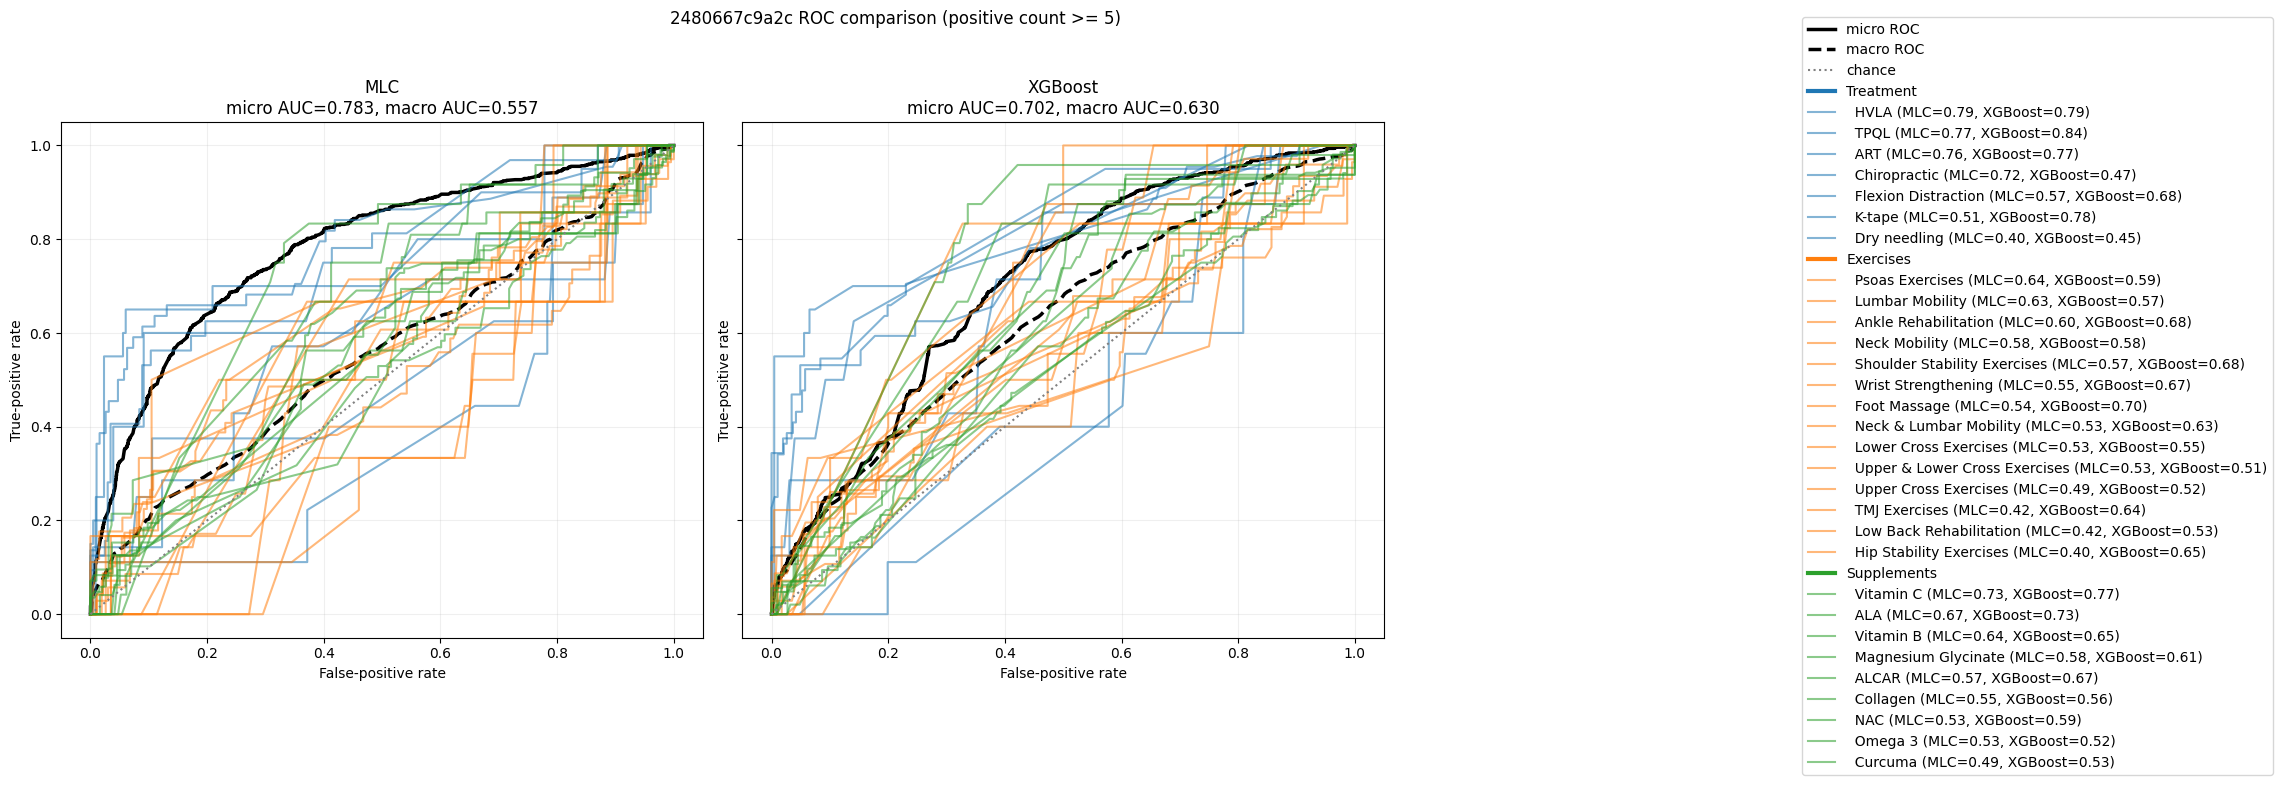

32 labels meet the minimum; plotting the top 30 by ROC-AUC.


,group,positive_count,mlc_roc_auc,benchmark_roc_auc,auc_delta
label,,,,,
HVLA,Treatment,44,0.793253,0.790516,0.002737
TPQL,Treatment,20,0.773721,0.843488,-0.069767
ART,Treatment,32,0.762315,0.773784,-0.011469
Chiropractic,Treatment,5,0.715652,0.469565,0.246087
Flexion Distraction,Treatment,7,0.571115,0.678571,-0.107456
K-tape,Treatment,8,0.510738,0.776432,-0.265694
Dry needling,Treatment,9,0.400688,0.446903,-0.046214
Psoas Exercises,Exercises,6,0.642649,0.589520,0.053130
Lumbar Mobility,Exercises,46,0.626409,0.567058,0.059351


In [10]:
MIN_LABEL_COUNT = 5
TOP_N_AUC_LABELS = 30

project_groups = [
    name
    for name, columns in project.items()
    if name not in {"features", "labels"} and isinstance(columns, list)
]

def label_group(label):
    for group in project_groups:
        if label in project[group]:
            return group
    source_label = re.sub(r"\.\d+$", "", label)
    for group in project_groups:
        if source_label in project[group]:
            return group
    return "Unclassified"

eligible_labels = per_label.loc[
    per_label["roc_auc"].notna()
    & (per_label["positive_count"] >= MIN_LABEL_COUNT)
].copy()
if eligible_labels.empty:
    raise ValueError(f"No labels have at least {MIN_LABEL_COUNT} positive test samples")
eligible_labels["benchmark_roc_auc"] = benchmark_per_label.loc[
    eligible_labels.index, "roc_auc"
]
eligible_labels["auc_delta"] = (
    eligible_labels["roc_auc"] - eligible_labels["benchmark_roc_auc"]
)

top_auc_labels = eligible_labels.nlargest(TOP_N_AUC_LABELS, "roc_auc").copy()
top_auc_labels["group"] = [label_group(label) for label in top_auc_labels.index]
plotted_groups = [
    group for group in project_groups + ["Unclassified"]
    if group in set(top_auc_labels["group"])
]
top_auc_labels = pd.concat(
    [
        top_auc_labels.loc[top_auc_labels["group"] == group].sort_values(
            "roc_auc", ascending=False
        )
        for group in plotted_groups
    ]
)
palette = plt.get_cmap("tab10").colors
group_colors = {group: palette[index % len(palette)] for index, group in enumerate(plotted_groups)}

eligible_indices = [label_columns.index(label) for label in eligible_labels.index]
eligible_mask = mask_array[:, eligible_indices]
eligible_targets = target_array[:, eligible_indices][eligible_mask]
eligible_scores = probability_array[:, eligible_indices][eligible_mask]

def roc_summary(score_array):
    flat_scores = score_array[:, eligible_indices][eligible_mask]
    micro_fpr, micro_tpr, _ = roc_curve(eligible_targets, flat_scores)
    mean_fpr = np.linspace(0, 1, 200)
    interpolated_tprs = []
    for label in eligible_labels.index:
        index = label_columns.index(label)
        observed = mask_array[:, index]
        fpr, tpr, _ = roc_curve(
            target_array[observed, index], score_array[observed, index]
        )
        interpolated_tprs.append(np.interp(mean_fpr, fpr, tpr))
    mean_tpr = np.mean(interpolated_tprs, axis=0)
    mean_tpr[0], mean_tpr[-1] = 0.0, 1.0
    return {
        "micro_fpr": micro_fpr,
        "micro_tpr": micro_tpr,
        "micro_auc": roc_auc_score(eligible_targets, flat_scores),
        "mean_fpr": mean_fpr,
        "mean_tpr": mean_tpr,
        "macro_auc": auc(mean_fpr, mean_tpr),
    }

mlc_roc = roc_summary(probability_array)
benchmark_roc = roc_summary(benchmark_probability_array)
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=True, sharey=True)
curve_handles = {}
for axis, name, score_array, summary_metrics in [
    (axes[0], "MLC", probability_array, mlc_roc),
    (axes[1], benchmark_name, benchmark_probability_array, benchmark_roc),
]:
    axis.plot(
        summary_metrics["micro_fpr"], summary_metrics["micro_tpr"],
        color="black", linewidth=2.5,
    )
    axis.plot(
        summary_metrics["mean_fpr"], summary_metrics["mean_tpr"],
        color="black", linestyle="--", linewidth=2.5,
    )
    for label, row in top_auc_labels.iterrows():
        index = label_columns.index(label)
        observed = mask_array[:, index]
        fpr, tpr, _ = roc_curve(
            target_array[observed, index], score_array[observed, index]
        )
        line, = axis.plot(
            fpr, tpr, color=group_colors[row["group"]], alpha=0.55
        )
        curve_handles.setdefault(label, line)
    axis.plot([0, 1], [0, 1], color="grey", linestyle=":")
    axis.set(
        xlabel="False-positive rate",
        ylabel="True-positive rate",
        title=(
            f"{name}\n"
            f"micro AUC={summary_metrics['micro_auc']:.3f}, "
            f"macro AUC={summary_metrics['macro_auc']:.3f}"
        ),
    )
    axis.grid(alpha=0.2)
legend_handles = [
    Line2D([0], [0], color="black", linewidth=2.5),
    Line2D([0], [0], color="black", linestyle="--", linewidth=2.5),
    Line2D([0], [0], color="grey", linestyle=":"),
]
legend_labels = ["micro ROC", "macro ROC", "chance"]
for group in plotted_groups:
    legend_handles.append(Line2D([0], [0], color=group_colors[group], linewidth=3))
    legend_labels.append(group)
    for label, row in top_auc_labels.loc[top_auc_labels["group"] == group].iterrows():
        legend_handles.append(curve_handles[label])
        legend_labels.append(
            f"  {label} (MLC={row['roc_auc']:.2f}, "
            f"{benchmark_name}={row['benchmark_roc_auc']:.2f})"
        )
fig.suptitle(f"{RUN_ID} ROC comparison (positive count >= {MIN_LABEL_COUNT})")
fig.legend(legend_handles, legend_labels, bbox_to_anchor=(1.0, 0.98), loc="upper left")
plt.tight_layout(rect=[0, 0, 0.78, 0.95])
plt.show()
print(
    f"{len(eligible_labels)} labels meet the minimum; "
    f"plotting the top {len(top_auc_labels)} by ROC-AUC."
)
display(
    top_auc_labels[
        ["group", "positive_count", "roc_auc", "benchmark_roc_auc", "auc_delta"]
    ].rename(columns={"roc_auc": "mlc_roc_auc"})
)

## Test precision-recall curves

Show the MLC precision-recall curves using the same minimum-count filter, top-AUC labels, colors, and project-grouped legend as the ROC comparison.

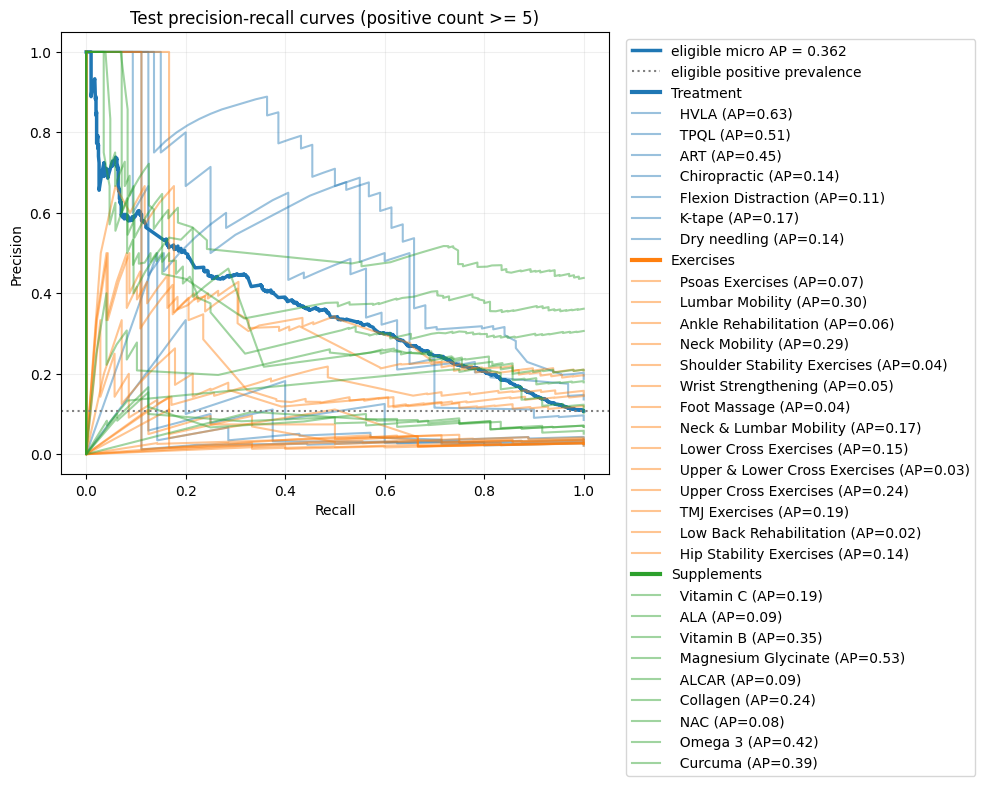

In [11]:
micro_precision_curve, micro_recall_curve, _ = precision_recall_curve(
    eligible_targets, eligible_scores
)
micro_average_precision = average_precision_score(eligible_targets, eligible_scores)
fig, axis = plt.subplots(figsize=(10, 7))
micro_pr_line, = axis.plot(
    micro_recall_curve,
    micro_precision_curve,
    linewidth=2.5,
)
pr_curve_handles = {}
for label, row in top_auc_labels.iterrows():
    index = label_columns.index(label)
    observed = mask_array[:, index]
    precision_curve, recall_curve, _ = precision_recall_curve(
        target_array[observed, index], probability_array[observed, index]
    )
    pr_curve_handles[label], = axis.plot(
        recall_curve,
        precision_curve,
        color=group_colors[row["group"]],
        alpha=0.45,
    )
prevalence_line = axis.axhline(
    eligible_targets.mean(), color="grey", linestyle=":"
)
legend_handles = [micro_pr_line, prevalence_line]
legend_labels = [
    f"eligible micro AP = {micro_average_precision:.3f}",
    "eligible positive prevalence",
]
for group in plotted_groups:
    legend_handles.append(Line2D([0], [0], color=group_colors[group], linewidth=3))
    legend_labels.append(group)
    for label, row in top_auc_labels.loc[top_auc_labels["group"] == group].iterrows():
        legend_handles.append(pr_curve_handles[label])
        legend_labels.append(
            f"  {label} (AP={row['average_precision']:.2f})"
        )
axis.set(
    xlabel="Recall",
    ylabel="Precision",
    title=f"Test precision-recall curves (positive count >= {MIN_LABEL_COUNT})",
)
axis.grid(alpha=0.2)
axis.legend(legend_handles, legend_labels, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()